In [1]:
import numpy as np
import json
import torch
from torchsummary import summary
from tqdm import tqdm
from pathlib import Path

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is not available. PyTorch is using CPU.


In [3]:
from src.models.base_model import base_model
from src.utils.metrics import AverageMeter, CombinedLoss, DiceLoss, dice_coefficient, iou_score, pixel_accuracy

Пути к каталогам.

In [4]:
config_dir = Path("./src/config/")
model_name = 'base-model'

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

model_config_path = config_dir / f"{model_name}-config.json"
assert model_config_path.exists(), f"Config not found: {model_config_path}"
with open(model_config_path, "r") as f:
    model_config = json.load(f)

dataset_config_path = config_dir / f"{model_config['dataset_name']}-config.json"
assert dataset_config_path.exists(), f"Config not found: {dataset_config_path}"
with open(dataset_config_path, "r") as f:
    dataset_config = json.load(f)
    
data_path = Path(general_config['data_dir']) / dataset_config['dataset_name']
checkpoints_dir = Path(general_config['checkpoints_dir'])

In [5]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

# Тест архитектуры

In [6]:
mdl_input_size = model_config['input_size']

model = base_model(
    in_channels = mdl_input_size[0],
    out_channels = 4,
    features = model_config['feature_list'],
    #device = self.device
    )
model = model.to(device)
model.eval()

test_input = torch.randn(1, *mdl_input_size).to(device)
test_output = model(test_input)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size}")
print(f"  Input:  {test_input.shape}")
print(f"  Output: {test_output.shape}")
summary(model, tuple(mdl_input_size))

Encoder features by level: [8, 16, 32]
Model size: 39484
  Input:  torch.Size([1, 2, 512])
  Output: torch.Size([1, 4, 512])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
    InstanceNorm1d-1               [-1, 2, 512]               4
       BatchNorm1d-2               [-1, 2, 512]               4
            Conv1d-3               [-1, 8, 256]             520
       BatchNorm1d-4               [-1, 8, 256]              16
              ReLU-5               [-1, 8, 256]               0
            Conv1d-6               [-1, 8, 128]           1,032
       BatchNorm1d-7               [-1, 2, 512]               4
            Conv1d-8               [-1, 8, 256]             264
       BatchNorm1d-9               [-1, 8, 256]              16
             ReLU-10               [-1, 8, 256]               0
           Conv1d-11               [-1, 8, 128]             520
      BatchNorm1d-12               [-1, 8,

In [7]:
test_output

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.2408, 0.1600, 0.2104,  ..., 0.1528, 0.2441, 0.2314],
         [0.3395, 0.2502, 0.2101,  ..., 0.2128, 0.2622, 0.2597],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
       grad_fn=<ReluBackward0>)

## dataloader

In [8]:
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [9]:
from src.dataloaders.ZerosPolesDataset import TransformsConfig, ZerosPolesDataset
from torch.utils.data import DataLoader
# Setting seeds.
def worker_init_fn(worker_id):
    np.random.seed(torch.initial_seed() % 2 ** 32)
    
train_transforms = TransformsConfig(
    #crop_ratio=[1.0, 1.0],
    time_delay=[0.0, 1e-9],
    noise_level=[5e-3, 30e-3],
    noise_reduce=2,
    gain=[0.9, 1.1]
)
val_transforms = None

train_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'train',
        mask_halfwindow=model_config["mask_halfwindow"],
        transforms=train_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=True,
    num_workers=0,#model_config["workers"],
    worker_init_fn=worker_init_fn,
    pin_memory=True)

val_loader = DataLoader(
    ZerosPolesDataset(
        dataset_dir = Path(general_config['data_dir']) / dataset_config['dataset_name'],
        split = 'val',
        mask_halfwindow=model_config["mask_halfwindow"],
        transforms=val_transforms
        ),
    batch_size=model_config["batch_size"],
    shuffle=False,
    num_workers=model_config["workers"],
    pin_memory=True)

In [10]:
checkpoints_file = checkpoints_dir / f"best_{model_name}.pth"
assert checkpoints_file.exists(), f"Checkpoints not found: {checkpoints_file}"

from src.models.model_utilizer import load_net

model, epoch, _, _ = load_net(
                net=model,
                checkpoints_file=checkpoints_file,
                device=device
        )

model.eval()

Restoring checkpoint:  checkpoints\best_base-model.pth


_base_model(
  (input_norm): InstanceNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (encoder1_1): Sequential(
    (0): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv1d(2, 8, kernel_size=(32,), stride=(2,), padding=(15,))
    (2): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Conv1d(8, 8, kernel_size=(16,), stride=(2,), padding=(7,))
  )
  (encoder1_2): Sequential(
    (0): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): Conv1d(8, 16, kernel_size=(16,), stride=(2,), padding=(7,))
    (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU(inplace=True)
    (5): Conv1d(16, 16, kernel_size=(8,), stride=(2,), padding=(3,))
  )
  (encoder1_3): Sequential(
    (0): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

def visualize_predictions(
    logits_all,
    masks_all,
    threshold: float=0.5,
    columns: int=1
    ):
    
    predictions_all = (torch.sigmoid(logits_all) > threshold).float().cpu()
    masks_all = masks_all.cpu()
    
    num_samples = len(masks_all)
    
    fig, axes = plt.subplots(num_samples//columns, columns, figsize=(8*columns, 2*num_samples/columns), constrained_layout=True)
    axes = axes.flatten()
       
    COLOR_OVERLAP = np.array([0.55, 0.27, 0.07])
    COLOR_TRUE_ONLY = np.array([0.75, 0.75, 0.75])
    COLOR_PRED_ONLY = np.array([0.25, 0.25, 0.25])
    
    for idx, masks, predictions, logits in zip(range(num_samples), masks_all, predictions_all, logits_all):
        mask_true = np.array(masks, dtype=bool)
        mask_pred = np.array(predictions, dtype=bool)
        
        mask_true_only = mask_true & (~mask_pred)
        mask_pred_only = (~mask_true) & mask_pred
        mask_overlap = mask_true & mask_pred      
       
        h, w = mask_true.shape
        # Start with white background.
        mask_rgb = np.ones((h, w, 3))
        
        mask_rgb[mask_overlap] = COLOR_OVERLAP
        mask_rgb[mask_true_only] = COLOR_TRUE_ONLY
        mask_rgb[mask_pred_only] = COLOR_PRED_ONLY
        
        axes[idx].imshow(mask_rgb, aspect='auto', interpolation='nearest')
        axes[idx].set_title(
            f'Sample {idx}: '
            f'Dice={dice_coefficient(logits.unsqueeze(0), masks.unsqueeze(0)):.4f}, '
            f'IoU={iou_score(logits.unsqueeze(0), masks.unsqueeze(0)):.4f}',
            fontsize=10
        )
        
    legend_elements = [
        mpatches.Patch(facecolor=COLOR_OVERLAP, edgecolor='black', label='Overlap'),
        mpatches.Patch(facecolor=COLOR_TRUE_ONLY, edgecolor='black', label='True'),
        mpatches.Patch(facecolor=COLOR_PRED_ONLY, edgecolor='black', label='Predicted')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
               ncol=len(legend_elements), fontsize=10, frameon=True)
    
    plt.show()
    plt.close(fig)

C:\Users\g5059\AppData\Local\Temp\ipykernel_22132\747736172.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_true = np.array(masks, dtype=bool)
C:\Users\g5059\AppData\Local\Temp\ipykernel_22132\747736172.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask_pred = np.array(predictions, dtype=bool)


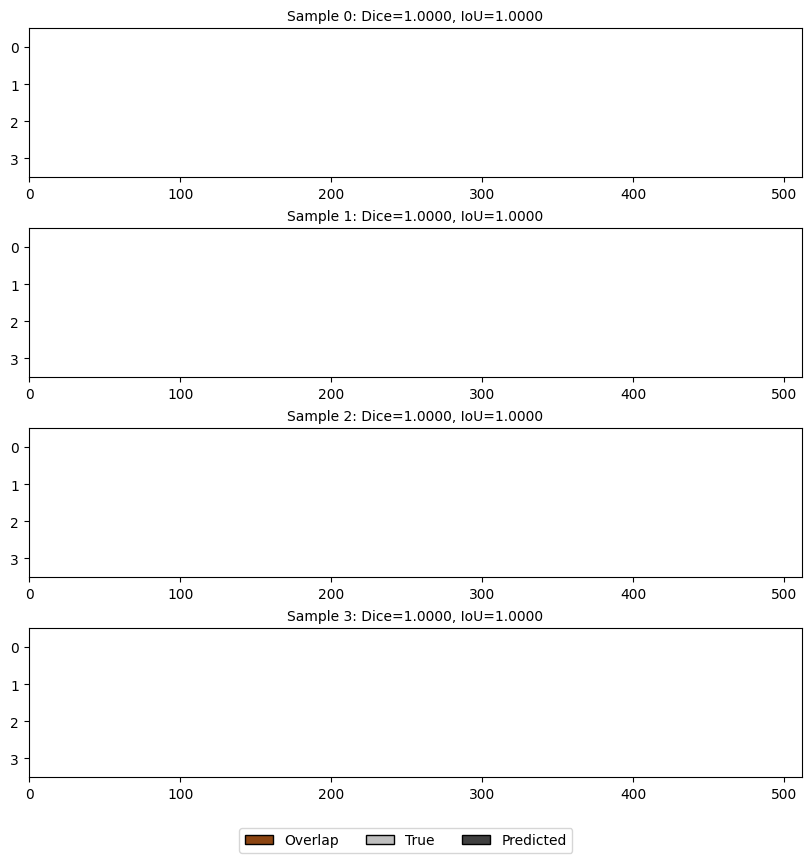

In [38]:
num_samples = 4
inputs, masks, _ = next(iter(val_loader))

# Get random indices from the batch
batch_size = inputs.shape[0]
random_indices = random.sample(range(batch_size), num_samples)

# Select random samples using the indices
inputs = inputs[random_indices]
masks = masks[random_indices]

with torch.no_grad():
        logits = model(inputs.to(device))

visualize_predictions(
        logits_all=logits.detach(),
        masks_all=masks,
        threshold=0.5,
        columns=1
        )

In [54]:
from src.dataloaders.ZerosPolesDataset import positions_to_mask

dataset_dir = Path(general_config["data_dir"]) / dataset_config["dataset_name"]

split = 'test'

mask_path = dataset_dir / (split + "_masks.json")
assert mask_path.exists(), f"Mask not found: {mask_path}"
with open(mask_path, "r") as f:
    masks = json.load(f)
    

sample_id = '1zp2lp1rp2lz1rz_019'

dataset_path = dataset_dir / split
sample_path = dataset_path / f"{sample_id}.csv"

if not sample_path.exists():
    raise FileNotFoundError(f"File not found: {sample_path}")

data_np = np.loadtxt(dataset_path / f"{sample_id}.csv", delimiter=',', skiprows=1)
data_tensor = torch.from_numpy(data_np.T).float()

mask_dict = masks[sample_id]
masks_list = []
for key, positions in mask_dict.items():
    if key == 'zero_poles':
        continue
    masks_list.append(
        positions_to_mask(
            positions=positions,
            total_bits=data_tensor.shape[-1],
            halfwindow=model_config["mask_halfwindow"]
            )
        )
masks_tensor = torch.from_numpy(np.vstack(masks_list)).float()
data_tensor = data_tensor[1:,:]

In [55]:
# 1. Initialize accumulators (use float64 for numerical stability)
channel_sum = None
channel_sum_sq = None
total_samples = 0  # Total number of scalar values per channel

# 2. Iterate over dataset
with torch.no_grad():
    for data_tuple in tqdm(val_loader, desc="Calculating Stats"):
        inputs = data_tuple[0].to(device)
        
        inputs = inputs.float()
        B, C, L = inputs.shape  # [Batch, Channels, Length]
        
        # Initialize on first batch (handles dynamic channel count)
        if channel_sum is None:
            channel_sum = torch.zeros(C, dtype=torch.float64, device=device)
            channel_sum_sq = torch.zeros(C, dtype=torch.float64, device=device)
        
        # 3. Accumulate sum and sum of squares per channel
        # Sum over Batch (0) and Length (2), keep Channel (1)
        channel_sum += inputs.sum(dim=(0, 2)).double()
        channel_sum_sq += (inputs ** 2).sum(dim=(0, 2)).double()
        
        # Count total samples per channel: Batch * Length
        total_samples += B * L

# 4. Compute Final Mean and Std
mean = channel_sum / total_samples
# Variance = E[X²] - (E[X])²
var = (channel_sum_sq / total_samples) - (mean ** 2)

mean = mean.cpu()
std = torch.sqrt(var).cpu()

print(f"Mean: {mean.numpy()}")
print(f"Std:  {std.numpy()}")

Calculating Stats: 100%|██████████| 20/20 [00:14<00:00,  1.40it/s]

Mean: [73.78254582 56.64125688]
Std:  [1931.63342489 1482.18908522]


## Run 1:
- Mean: [ 984.91466768 2397.26128974]
- Std:  [ 55818.49198814 218841.79374928]

## Run 2:
- Mean: [1001.5774273 2397.346644 ]
- Std:  [ 57678.93105483 218281.70283202]

## Run 3:
- Mean: [1014.77855625 2394.29139941]
- Std:  [ 59264.07932032 217862.15627679]

In [56]:
with torch.no_grad():
    
    inputs, masks, _ = next(iter(val_loader))
    inputs, masks = inputs.to(device), masks.to(device)
    
    outputs = model(inputs)
        
    print(dice_coefficient(outputs.detach(), masks.detach()))
    print(iou_score(outputs.detach(), masks.detach()))
    
    '''
    for data_tuple in tqdm(val_loader, desc="Val"):
        
        inputs, masks = data_tuple[0].to(device), data_tuple[1].to(device)
        
        outputs = model(inputs)
        
        print(dice_coefficient(outputs.detach(), masks.detach()))
        print(iou_score(outputs.detach(), masks.detach()))
    '''

0.528163731098175
0.527982234954834
